# Bayesian Mixture Model Analysis of Running Activity Distances
### An assignment for MATH574 Bayesian Computational Statistics at Illinois Tech
### Author: Warwick Simpson

### Introduction
This report details the application of a Bayesian finite mixture model to analyze the authors running activity data from the fitness tracking platform Strava. A mixture model was chosen as the author noticed his run training seemed to operate in two modes - a “routine” run that was very common about 9km, and mainly chosen for the length of time it took (i.e. less than an hour), and a more varied approach to training distances that occurred when following a training plan for a marathon or similar.

This notebook is intended to accompany the report "Project 3: Bayesian Mixture Model Analysis of Running Activity Distances.pdf"

# Table of Contents
1. [Data Preparation](#data-preparation)
2. [Fitting with Stan](#fitting-with-stan)
3. [Convergence Diagnostics](#convergence-diagnostics)
4. [Posterior Predictive Check](#posterior-predictive-check)
5. [Posterior Prediction and Classification](#posterior-prediction-and-classification)
6. [Prior Sensitivity Check](#prior-sensitivity-check)
7. [Log-normal Mixture Model For Comparison](#log-normal-mixture-model-for-comparison)


In [1]:
# Load necessary libraries

library(rstan)
library(tidyverse)
library(bayesplot)
library(rstanarm)

# Set Stan options for faster compiling
rstan_options(auto_write = TRUE)
options(mc.cores = parallel::detectCores())

Loading required package: StanHeaders


rstan version 2.32.7 (Stan version 2.32.2)


For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threads_per_chain` option:
rstan_options(threads_per_chain = 1)


Do not specify '-march=native' in 'LOCAL_CPPFLAGS' or a Makevars file

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::extract() masks rstan::extract()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag

## Data Preparation
<a id="data-preparation"></a>

In [2]:
#Load the raw data and inspect

raw_data <- read.csv(file = "activities.csv")
head(raw_data)

,Activity.ID,Activity.Date,Activity.Name,Activity.Type,Activity.Description,Elapsed.Time,Distance,Max.Heart.Rate,Relative.Effort,Commute,⋯,Intensity,Average.Grade.Adjusted.Pace,Timer.Time,Total.Cycles,Recovery,With.Pet,Competition,Long.Run,For.a.Cause,Media
,<dbl>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<int>,<chr>,⋯,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<chr>
1,9160582051,"May 29, 2023, 2:54:38 AM",Afternoon Trail Run,Run,,3624,10.23,NA,NA,false,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,
2,9173360920,"May 30, 2023, 10:06:33 PM",Morning Run,Run,,3798,12.55,NA,NA,false,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,
3,9178731525,"May 31, 2023, 9:38:13 PM",Morning Run,Run,,2262,4.91,NA,NA,false,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,
4,9197195271,"Jun 3, 2023, 8:45:03 PM",Morning Trail Run,Run,,4155,11.04,171,88,false,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,
5,9204277641,"Jun 4, 2023, 9:25:35 PM",Morning Trail Run with Casey,Run,,2735,6.55,156,19,false,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,
6,9216606315,"Jun 6, 2023, 9:03:42 PM",Morning Run,Run,,4295,14.17,174,150,false,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,


Total number of filtered runs: 220
Minimum Distance: 0.34 km, Maximum Distance: 42.29 km


Warning message:
"The dot-dot notation (`..count..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(count)` instead."


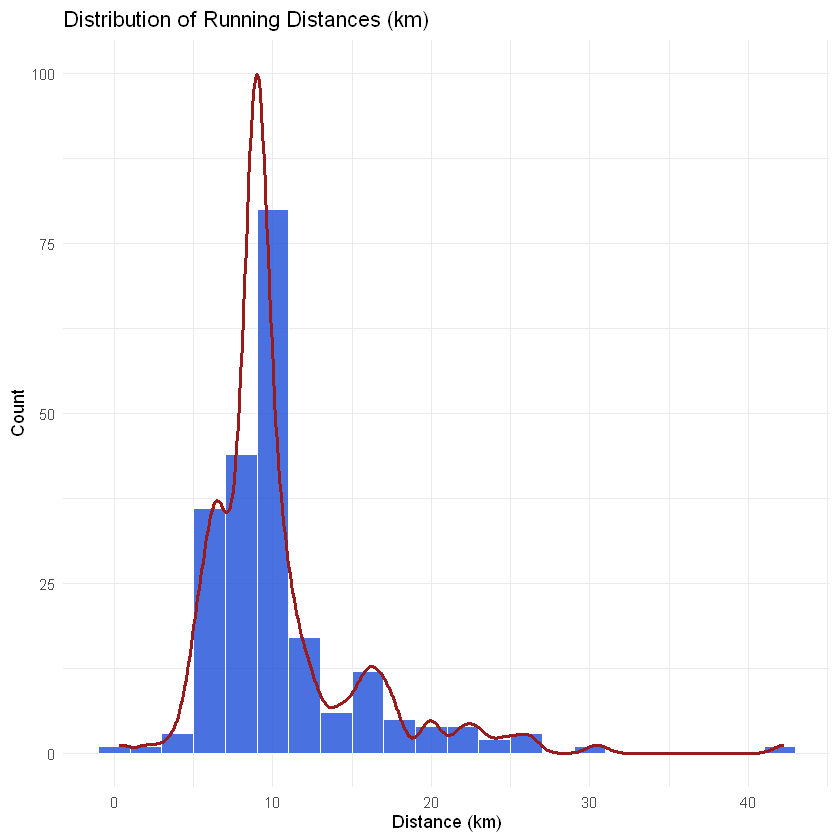

In [3]:
# 1. Filter for 'Run' activities, convert Distance to double, and filter out non-positive values

run_data <- raw_data %>%
  filter(`Activity.Type` == "Run") %>%
  mutate(
    Distance = as.double(Distance),
    # Convert the character date to POSIXct object for plotting the timeline
    Activity.Date = as.POSIXct(Activity.Date, format = "%b %d, %Y, %I:%M:%S %p")
  ) %>% 
  select(Activity.Date, Distance) %>% 
  filter(Distance > 0) # Only include positive distances

# Prepare data for Stan
Y <- run_data$Distance
N <- length(Y)

cat(sprintf("Total number of filtered runs: %d\n", N))
cat(sprintf("Minimum Distance: %.2f km, Maximum Distance: %.2f km\n", min(Y), max(Y)))

# Plot the distribution of distances
ggplot(run_data, aes(x = Distance)) +
  geom_histogram(binwidth = 2, fill = "#1d4ed8", color="white", alpha=0.8) +
  geom_density(aes(y = ..count.. * 2), color="#991b1b", linewidth=1) +
  labs(title = "Distribution of Running Distances (km)",
       x = "Distance (km)",
       y = "Count") +
  theme_minimal()

## Fitting with Stan
<a id="fitting-with-stan"></a>
Note the model for stan is in the separate file mixture_model.stan

In [4]:
# Data preparation for Stan
stan_data <- list(N = N, y = Y)

# Set seed of random number generator for repeatability
#set.seed(1)

# Run the sampler
# Setting iter to 2000 and chains to 4 is a reasonable starting point.
fit <- stan(
  file = "mixture_model.stan", 
  data = stan_data, 
  iter = 4000, 
  chains = 4, 
  warmup = 2000,
  control = list(adapt_delta = 0.95, max_treedepth = 15) # Controls for potential convergence issues
)

## Convergence Diagnostics
<a id="convergence-diagnostics"></a>

Warning message in par(usr):
"argument 1 does not name a graphical parameter"
Warning message in par(usr):
"argument 1 does not name a graphical parameter"
Warning message in par(usr):
"argument 1 does not name a graphical parameter"
Warning message in par(usr):
"argument 1 does not name a graphical parameter"
Warning message in par(usr):
"argument 1 does not name a graphical parameter"


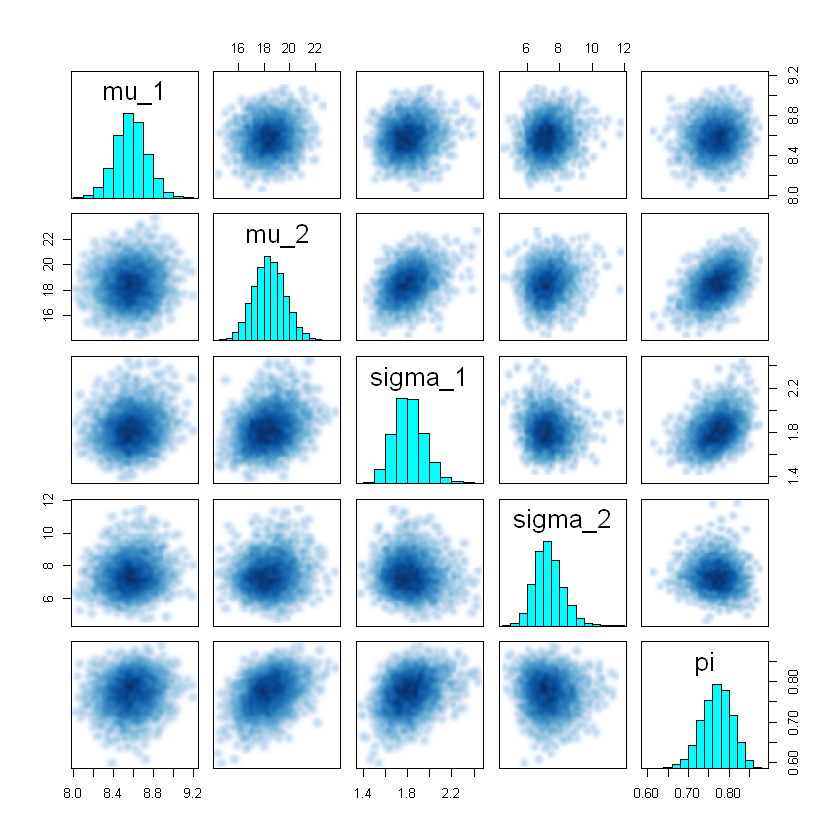

In [7]:
pairs(fit, pars=c("mu_1","mu_2","sigma_1","sigma_2","pi"))

Inference for Stan model: anon_model.
4 chains, each with iter=4000; warmup=2000; thin=1; 
post-warmup draws per chain=2000, total post-warmup draws=8000.

         mean se_mean   sd  2.5%   50% 97.5% n_eff Rhat
pi       0.77    0.00 0.04  0.69  0.77  0.84  5316    1
mu_1     8.58    0.00 0.16  8.27  8.57  8.89  7292    1
sigma_1  1.82    0.00 0.14  1.57  1.81  2.12  5483    1
mu_2    18.41    0.02 1.24 16.06 18.39 20.89  5169    1
sigma_2  7.32    0.01 0.86  5.82  7.26  9.18  6814    1

Samples were drawn using NUTS(diag_e) at Sat Nov 29 13:40:46 2025.
For each parameter, n_eff is a crude measure of effective sample size,
and Rhat is the potential scale reduction factor on split chains (at 
convergence, Rhat=1).


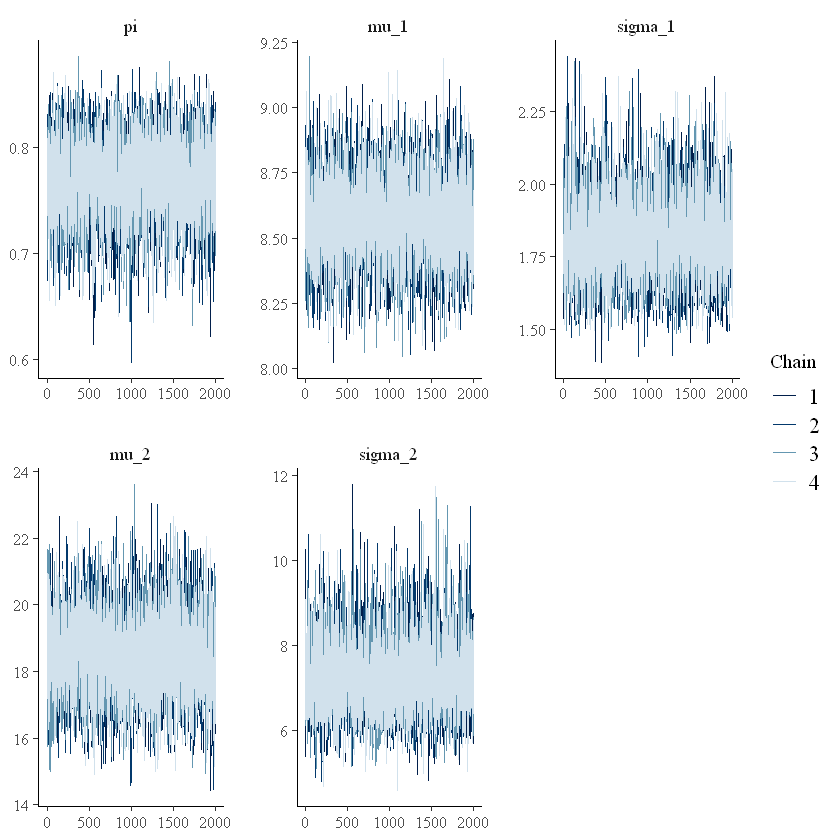

In [ ]:
# Print main parameters summary
print(fit, pars = c("pi", "mu_1", "sigma_1", "mu_2", "sigma_2"), probs = c(0.025, 0.5, 0.975))

# Plot traceplots for visual convergence check
mcmc_trace(fit, pars = c("pi", "mu_1", "sigma_1", "mu_2", "sigma_2"))


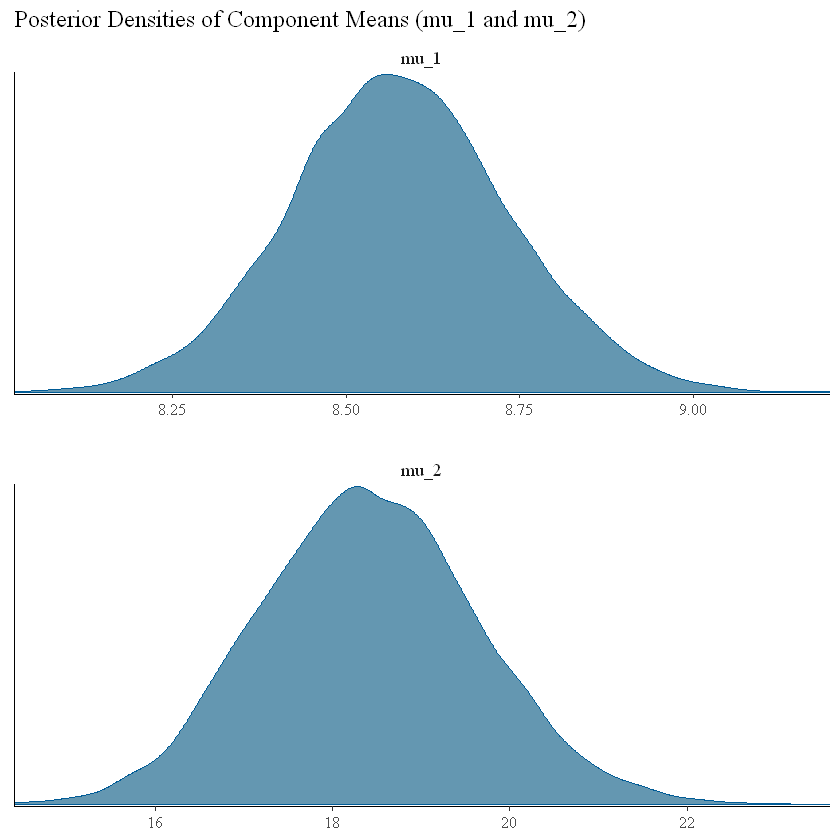

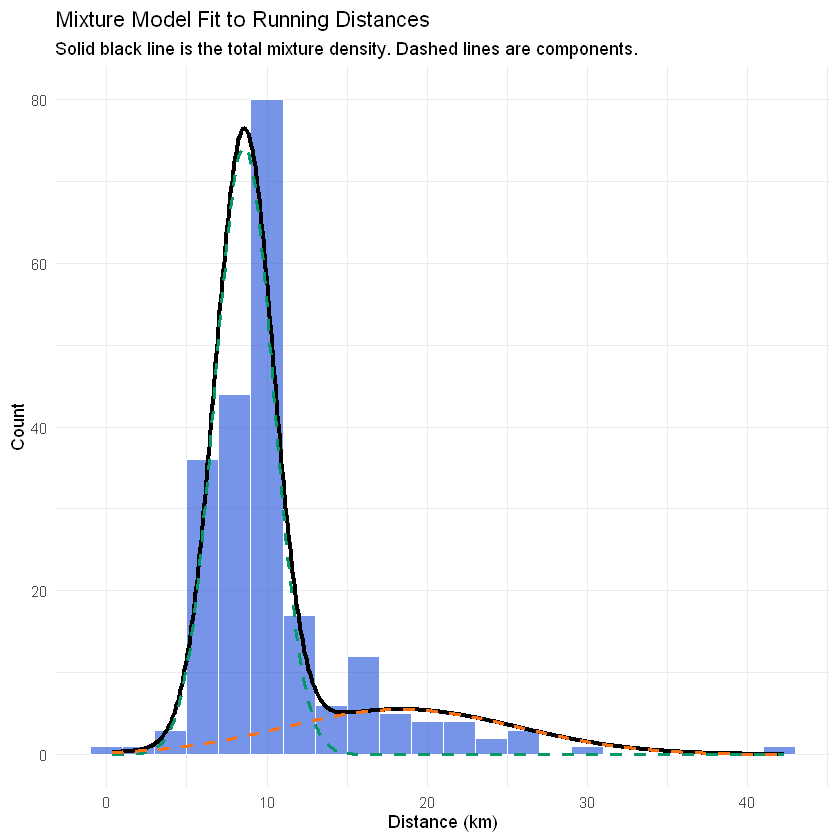

In [13]:
# Use the bayesplot functions to plot the posterior distribution of a relevant parameter
mcmc_dens(fit, pars = c("mu_1", "mu_2"), 
          facet_args = list(nrow = 2)) +
  labs(title = "Posterior Densities of Component Means (mu_1 and mu_2)")

# Plotting the model-implied density over the observed data histogram
# This is complex and often requires manual calculation, but is the most illustrative.
plot_data <- data.frame(Distance = Y)

# Get the posterior mean parameters for visualization (using converged values for display)
mu1_m <- 8.58
sigma1_m <- 1.82
mu2_m <- 18.41
sigma2_m <- 7.32
pi_m <- 0.77

# Create a sequence of distances for plotting the theoretical density
x_seq <- seq(min(Y), max(Y), length.out = 500)

# Calculate the mixture density based on the posterior means
mixture_density <- pi_m * dnorm(x_seq, mu1_m, sigma1_m) + 
                   (1 - pi_m) * dnorm(x_seq, mu2_m, sigma2_m)
component1_density <- pi_m * dnorm(x_seq, mu1_m, sigma1_m)
component2_density <- (1 - pi_m) * dnorm(x_seq, mu2_m, sigma2_m)

density_df <- data.frame(x = x_seq, total = mixture_density, comp1 = component1_density, comp2 = component2_density)

# Scale the densities to match the histogram counts (approx.)
bin_width <- 2
scale_factor <- N * bin_width

ggplot(plot_data, aes(x = Distance)) +
  geom_histogram(aes(y = ..count..), binwidth = bin_width, fill = "#1d4ed8", color="white", alpha=0.6) +
  
  # Total Mixture Density
  geom_line(data = density_df, aes(x = x, y = total * scale_factor), 
            color = "black", linewidth = 1.2) +
  
  # Component 1 Density (Routine)
  geom_line(data = density_df, aes(x = x, y = comp1 * scale_factor), 
            color = "#059669", linetype = "dashed", linewidth = 1) +
  
  # Component 2 Density (Training)
  geom_line(data = density_df, aes(x = x, y = comp2 * scale_factor), 
            color = "#f97316", linetype = "dashed", linewidth = 1) +
            
  labs(title = "Mixture Model Fit to Running Distances",
       subtitle = "Solid black line is the total mixture density. Dashed lines are components.",
       x = "Distance (km)",
       y = "Count") +
  theme_minimal()

## Posterior Predictive Check
To assess model fit, posterior predictive checks were performed by generating 1,000 synthetic datasets from the posterior distribution and comparing them to the observed data. Figure X shows the observed data density (black) overlaid with 50 randomly sampled posterior predictive densities (blue). The observed data falls well within the range of predicted distributions, indicating good model fit.

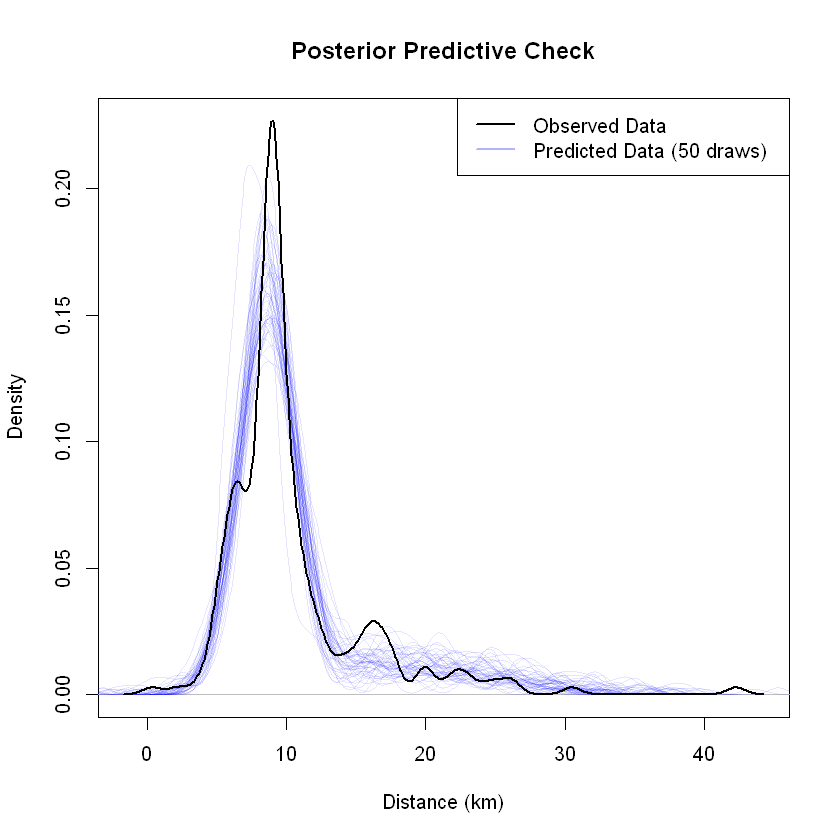

In [13]:
# Extract posterior samples from your Stan fit
posterior_samples <- rstan::extract(fit)

# Number of posterior draws to use (use all or sample, e.g., 1000)
n_draws <- 1000
n_obs <- 220  # Your actual sample size

# Generate predicted datasets
y_pred <- matrix(NA, nrow = n_draws, ncol = n_obs)

for (i in 1:n_draws) {
  # Extract parameters from this posterior draw
  pi <- posterior_samples$pi[i]
  mu1 <- posterior_samples$mu_1[i]
  sigma1 <- posterior_samples$sigma_1[i]
  mu2 <- posterior_samples$mu_2[i]
  sigma2 <- posterior_samples$sigma_2[i]
  
  # For each observation, sample from the mixture
  for (j in 1:n_obs) {
    # Decide which component based on mixing proportion
    if (runif(1) < pi) {
      # Sample from component 1 (routine)
      y_pred[i, j] <- rnorm(1, mu1, sigma1)
    } else {
      # Sample from component 2 (training)
      y_pred[i, j] <- rnorm(1, mu2, sigma2)
    }
  }
}

# Create plot
plot(density(run_data$Distance), 
     main = "Posterior Predictive Check",
     xlab = "Distance (km)", 
     ylab = "Density",
     lwd = 2, col = "black")

# Add several posterior predictive datasets (semi-transparent)
for (i in sample(1:n_draws, 50)) {  # Plot 50 random draws
  lines(density(y_pred[i, ]), col = rgb(0, 0, 1, 0.1))
}

# Re-draw observed data on top
lines(density(run_data$Distance), lwd = 2, col = "black")

legend("topright", 
       legend = c("Observed Data", "Predicted Data (50 draws)"),
       col = c("black", rgb(0, 0, 1, 0.3)), 
       lwd = c(2, 2))

## Posterior Prediction and Classification
<a id="posterior-prediction-and-classification"></a>


--- Classification of Observed Runs (First 6) ---
        Activity.Date Distance P_Training Predicted_Label
1 2023-05-29 02:54:38    10.23 0.05659809     1 (Routine)
2 2023-05-30 22:06:33    12.55 0.36785110     1 (Routine)
3 2023-05-31 21:38:13     4.91 0.09383922     1 (Routine)
4 2023-06-03 20:45:03    11.04 0.10033911     1 (Routine)
5 2023-06-04 21:25:35     6.55 0.03589515     1 (Routine)
6 2023-06-06 21:03:42    14.17 0.87533703    2 (Training)

Total runs classified as Routine (Component 1): 180
Total runs classified as Training (Component 2): 40


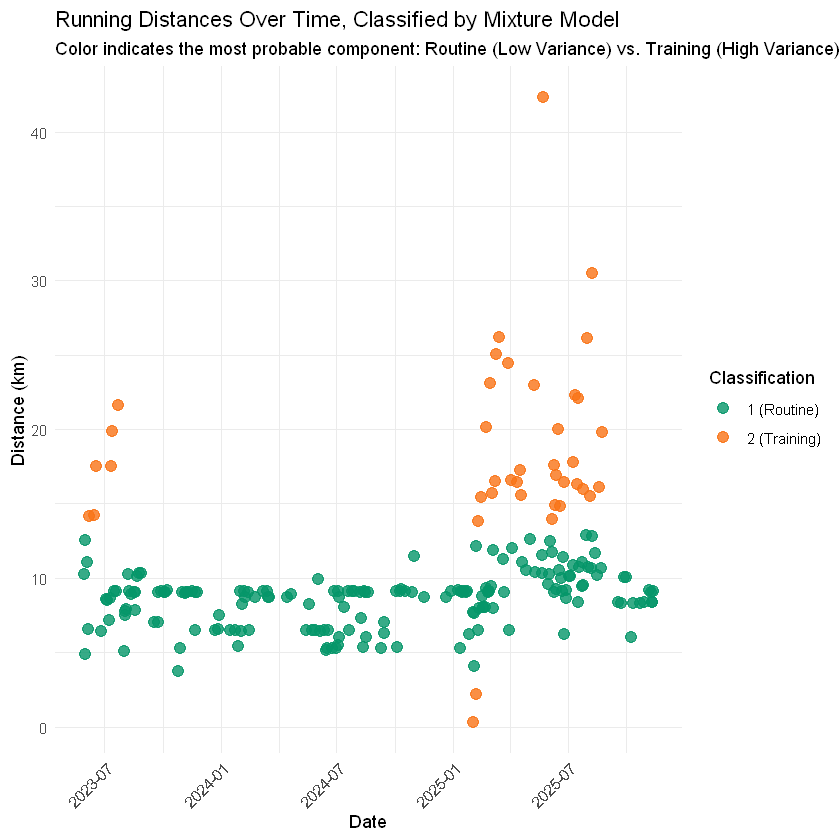

In [16]:
# The function to calculate the probability a run Y belongs to Component 2 (Training)
# P(k=2 | Y=y) = [ (1-pi) * f2(y) ] / [ pi*f1(y) + (1-pi)*f2(y) ]
P_k2_given_Y <- function(y, pi, mu1, sigma1, mu2, sigma2) {
  # Likelihood of y under component 1
  f1_y <- dnorm(y, mean = mu1, sd = sigma1)
  # Likelihood of y under component 2
  f2_y <- dnorm(y, mean = mu2, sd = sigma2)
  
  # Numerator: (1-pi) * f2(y)
  numerator <- (1 - pi) * f2_y
  # Denominator: pi * f1(y) + (1-pi) * f2(y)
  denominator <- pi * f1_y + (1 - pi) * f2_y
  
  return(numerator / denominator)
}

# Apply the function to the observed data Y (distances)
# We use the converged posterior mean parameters
classification_prob <- P_k2_given_Y(
  y = Y, 
  pi = pi_m, 
  mu1 = mu1_m, 
  sigma1 = sigma1_m, 
  mu2 = mu2_m, 
  sigma2 = sigma2_m
)

# Assign classification labels (1=Routine, 2=Training) based on >0.5 probability of Comp 2
classification_label <- ifelse(classification_prob > 0.5, 
                               "2 (Training)", 
                               "1 (Routine)")

# Combine results with the run_data containing dates and distances
classification_df <- run_data %>% 
  mutate(
    P_Training = classification_prob,
    Predicted_Label = classification_label
  )

cat("\n--- Classification of Observed Runs (First 6) ---\n")
print(head(classification_df))

cat(sprintf("\nTotal runs classified as Routine (Component 1): %d\n", sum(classification_label == "1 (Routine)")))
cat(sprintf("Total runs classified as Training (Component 2): %d\n", sum(classification_label == "2 (Training)")))

# Visualize the split as a time-series
ggplot(classification_df, aes(x = Activity.Date, y = Distance, color = Predicted_Label)) +
  geom_point(alpha = 0.8, size = 3) +
  labs(title = "Running Distances Over Time, Classified by Mixture Model",
       subtitle = "Color indicates the most probable component: Routine (Low Variance) vs. Training (High Variance)",
       x = "Date",
       y = "Distance (km)",
       color = "Classification") +
  scale_color_manual(values = c("1 (Routine)" = "#059669", "2 (Training)" = "#f97316")) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))



*** The classification threshold distance (P(Training | Y) = 0.5) is: **12.95 km** ***

Interpretation: Any run shorter than this distance is classified as 'Routine' (Component 1), and any run longer is classified as 'Training' (Component 2).
*** 95% Credible Interval for the Classification Threshold ***
Lower Bound (2.5%): **12.16 km**
Upper Bound (97.5%): **13.87 km**
The 95% CI for the threshold distance is: **[12.16 km, 13.87 km]**.


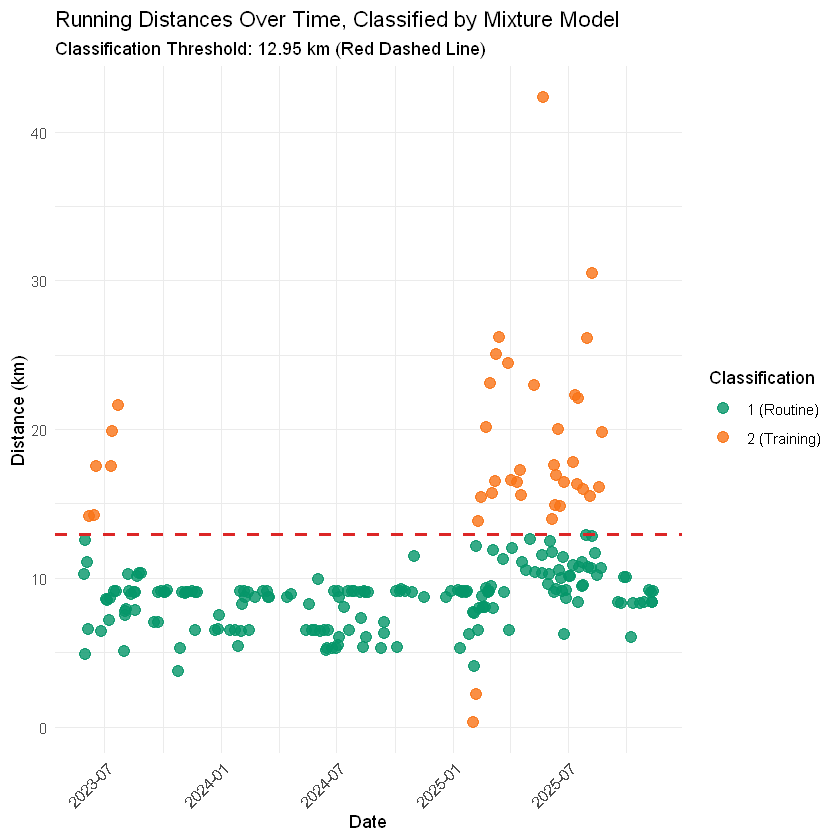

In [19]:
# Define the function whose root is the classification threshold.
# We look for y such that log(pi*f1(y)) = log((1-pi)*f2(y)), or 
# log((1-pi)*f2(y)) - log(pi*f1(y)) = 0
log_prob_difference <- function(y, pi, mu1, sigma1, mu2, sigma2) {
  # Log probability of Component 2 (Training)
  log_prob_comp2 <- log(1 - pi) + dnorm(y, mean = mu2, sd = sigma2, log = TRUE)
  
  # Log probability of Component 1 (Routine)
  log_prob_comp1 <- log(pi) + dnorm(y, mean = mu1, sd = sigma1, log = TRUE)
  
  # We look for the root where the log probabilities are equal
  return(log_prob_comp2 - log_prob_comp1)
}

# Find the root (the threshold distance) using the posterior mean parameters
# The root must lie between the two means (mu1_m and mu2_m)
root_interval <- c(mu1_m, mu2_m)

threshold_result <- uniroot(
  f = log_prob_difference,
  interval = root_interval, # Safe interval between the two means
  pi = pi_m, 
  mu1 = mu1_m, 
  sigma1 = sigma1_m, 
  mu2 = mu2_m, 
  sigma2 = sigma2_m
)

threshold_distance <- threshold_result$root

cat(sprintf("\n*** The classification threshold distance (P(Training | Y) = 0.5) is: **%.2f km** ***\n", threshold_distance))
cat("\nInterpretation: Any run shorter than this distance is classified as 'Routine' (Component 1), and any run longer is classified as 'Training' (Component 2).")

# -------------------------------------------------------------------------
# Calculate the 95% Credible Interval (CI) for the Threshold Distance
# -------------------------------------------------------------------------

# 1. Define a robust function to calculate the threshold distance for a single MCMC draw
calculate_threshold_for_draw <- function(pi, mu1, sigma1, mu2, sigma2) {
  # The log_prob_difference function is defined above.
  
  # Set the interval for uniroot. Check basic constraints before running.
  if (sigma1 <= 0 || sigma2 <= 0 || mu1 >= mu2 || pi <= 0.001 || pi >= 0.999) {
    return(NA) # Return NA if parameters are numerically invalid
  }
  
  # The root should lie between the two means.
  root_interval <- c(mu1, mu2)
  
  # Use tryCatch to handle potential uniroot failures (numerical stability issue)
  tryCatch({
    result <- uniroot(
      f = log_prob_difference,
      interval = root_interval,
      pi = pi, mu1 = mu1, sigma1 = sigma1, mu2 = mu2, sigma2 = sigma2
    )
    return(result$root)
  }, error = function(e) {
    return(NA) # Return NA if uniroot fails
  })
}

# 2. Apply the function across all MCMC posterior draws
# Extract posteriors for easier use
posterior_draws <- as.data.frame(fit, pars = c("pi", "mu_1", "sigma_1", "mu_2", "sigma_2"))
threshold_posterior <- apply(
  posterior_draws, 
  1,               # Apply row-wise (1=row)
  function(row) {
    calculate_threshold_for_draw(
      pi = row["pi"], 
      mu1 = row["mu_1"], 
      sigma1 = row["sigma_1"], 
      mu2 = row["mu_2"], 
      sigma2 = row["sigma_2"]
    )
  }
)

# 3. Filter out NAs and calculate the CI
threshold_posterior_valid <- threshold_posterior[!is.na(threshold_posterior)]

if (length(threshold_posterior_valid) > 100) { # Check for sufficient valid draws
  threshold_ci_low <- quantile(threshold_posterior_valid, 0.025)
  threshold_ci_high <- quantile(threshold_posterior_valid, 0.975)

  cat("\n*** 95% Credible Interval for the Classification Threshold ***\n")
  cat(sprintf("Lower Bound (2.5%%): **%.2f km**\n", threshold_ci_low)) 
  cat(sprintf("Upper Bound (97.5%%): **%.2f km**\n", threshold_ci_high)) 
  cat(sprintf("The 95%% CI for the threshold distance is: **[%.2f km, %.2f km]**.\n", threshold_ci_low, threshold_ci_high))
} else {
  cat("\nNote: Not enough valid MCMC draws were generated to calculate a reliable 95% CI for the threshold.\n")
}

# Visualize the split as a time-series, now including the threshold line
ggplot(classification_df, aes(x = Activity.Date, y = Distance, color = Predicted_Label)) +
  geom_point(alpha = 0.8, size = 3) +
  # Add the calculated threshold line
  geom_hline(yintercept = threshold_distance, linetype = "dashed", color = "#dc2626", linewidth = 1) +
  labs(title = "Running Distances Over Time, Classified by Mixture Model",
       subtitle = paste0("Classification Threshold: ", round(threshold_distance, 2), " km (Red Dashed Line)"),
       x = "Date",
       y = "Distance (km)",
       color = "Classification") +
  scale_color_manual(values = c("1 (Routine)" = "#059669", "2 (Training)" = "#f97316")) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

## Prior sensitivity check
<a id="prior-sensitivity-check"></a>
To check sensitivity to the priors, I re-fitted the model using priors for $\mu_1$ and $\mu_2$ with their variances doubled to 3 and 4 respectively.

Note mixture_model_wide.stan is identical to mixture_model.stan apart from the changed sds of the priors, so is not included in the project submission.

In [23]:
# Data preparation for Stan
stan_data <- list(N = N, y = Y)

# Set seed of random number generator for repeatability
set.seed(42)

# Run the sampler
# Setting iter to 2000 and chains to 4 is a reasonable starting point.
fit <- stan(
  file = "mixture_model_wide.stan", #using doubled sd (3 & 4) for priors of mu_1 and mu_2
  data = stan_data, 
  iter = 4000, 
  chains = 4, 
  warmup = 2000,
  control = list(adapt_delta = 0.95, max_treedepth = 15) # Controls for potential convergence issues
)

hash mismatch so recompiling; make sure Stan code ends with a blank line



Inference for Stan model: anon_model.
4 chains, each with iter=4000; warmup=2000; thin=1; 
post-warmup draws per chain=2000, total post-warmup draws=8000.

         mean se_mean   sd  2.5%   50% 97.5% n_eff Rhat
pi       0.74    0.00 0.04  0.65  0.74  0.82  5035    1
mu_1     8.56    0.00 0.16  8.25  8.56  8.87  6935    1
sigma_1  1.74    0.00 0.14  1.49  1.73  2.02  5388    1
mu_2    16.33    0.02 1.16 14.36 16.27 18.79  3935    1
sigma_2  7.23    0.01 0.74  5.95  7.16  8.84  6553    1

Samples were drawn using NUTS(diag_e) at Sun Nov 30 16:22:51 2025.
For each parameter, n_eff is a crude measure of effective sample size,
and Rhat is the potential scale reduction factor on split chains (at 
convergence, Rhat=1).


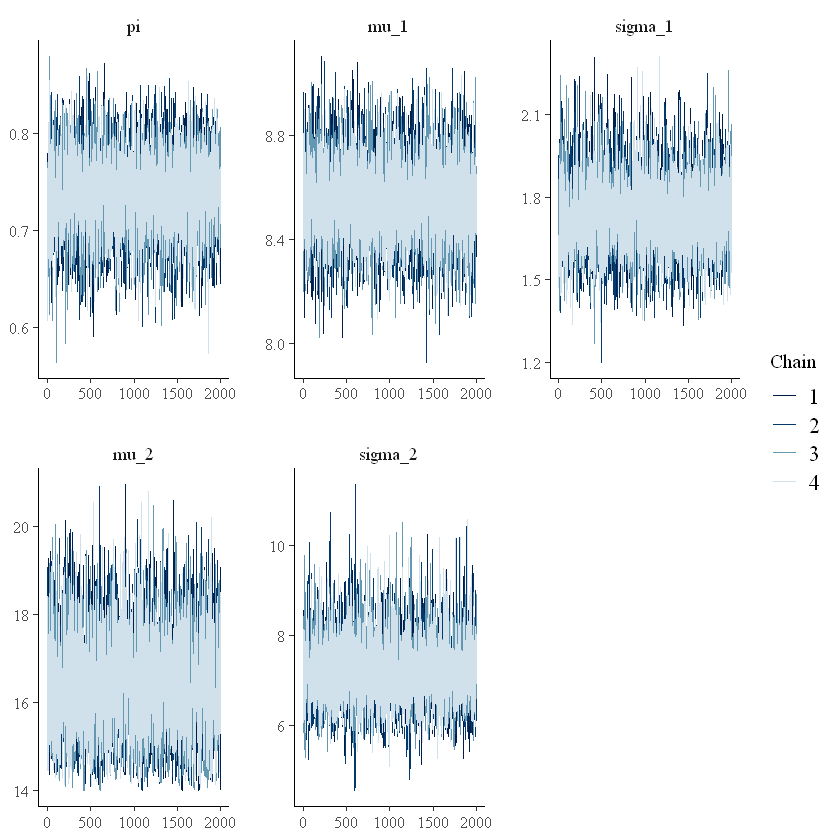

In [24]:
# Print main parameters summary
print(fit, pars = c("pi", "mu_1", "sigma_1", "mu_2", "sigma_2"), probs = c(0.025, 0.5, 0.975))

# Plot traceplots for visual convergence check
mcmc_trace(fit, pars = c("pi", "mu_1", "sigma_1", "mu_2", "sigma_2"))

Running with $\mu_2$ sd = 8

In [21]:
# Set seed of random number generator for repeatability
set.seed(42)

# Run the sampler
# Setting iter to 2000 and chains to 4 is a reasonable starting point.
fit <- stan(
  file = "mixture_model_wide.stan", #using doubled variance for priors of mu_1 and mu_2
  data = stan_data, 
  iter = 4000, 
  chains = 4, 
  warmup = 2000,
  control = list(adapt_delta = 0.95, max_treedepth = 15) # Controls for potential convergence issues
)

Inference for Stan model: anon_model.
4 chains, each with iter=4000; warmup=2000; thin=1; 
post-warmup draws per chain=2000, total post-warmup draws=8000.

         mean se_mean   sd  2.5%   50% 97.5% n_eff Rhat
pi       0.73    0.00 0.04  0.64  0.73  0.81  5773    1
mu_1     8.55    0.00 0.15  8.25  8.55  8.86  6210    1
sigma_1  1.72    0.00 0.14  1.47  1.71  2.01  5603    1
mu_2    15.71    0.02 1.04 14.15 15.57 18.07  4294    1
sigma_2  7.22    0.01 0.71  5.95  7.17  8.74  3147    1

Samples were drawn using NUTS(diag_e) at Sun Nov 30 16:17:09 2025.
For each parameter, n_eff is a crude measure of effective sample size,
and Rhat is the potential scale reduction factor on split chains (at 
convergence, Rhat=1).


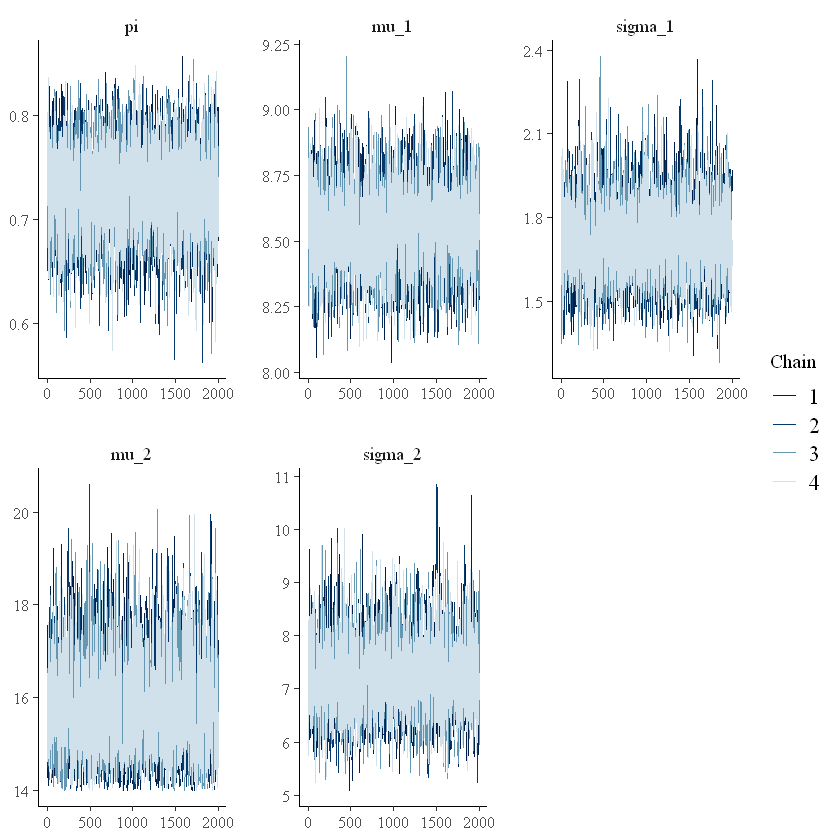

In [22]:
# Print main parameters summary
print(fit, pars = c("pi", "mu_1", "sigma_1", "mu_2", "sigma_2"), probs = c(0.025, 0.5, 0.975))

# Plot traceplots for visual convergence check
mcmc_trace(fit, pars = c("pi", "mu_1", "sigma_1", "mu_2", "sigma_2"))

Creating plot of the very weak prior model for comparison

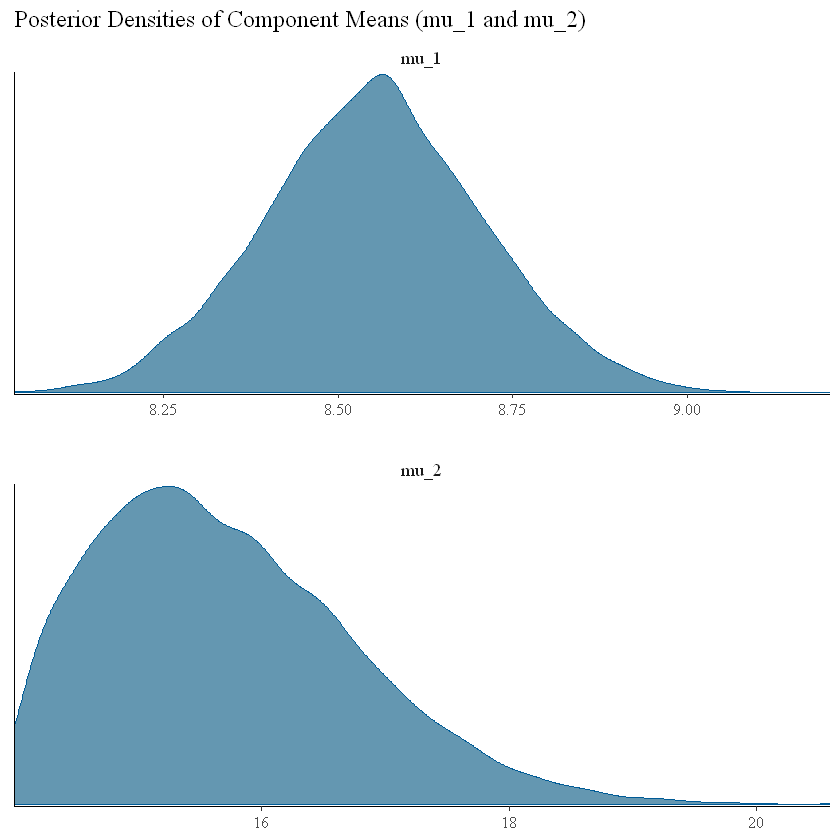

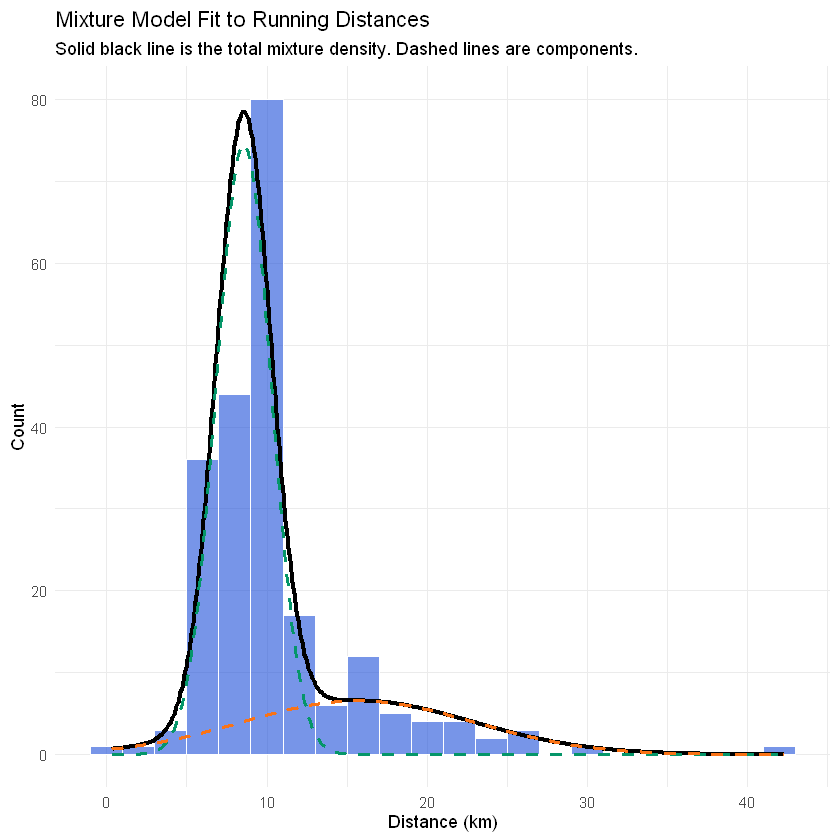

In [28]:
# Use the bayesplot functions to plot the posterior distribution of a relevant parameter
mcmc_dens(fit, pars = c("mu_1", "mu_2"), 
          facet_args = list(nrow = 2)) +
  labs(title = "Posterior Densities of Component Means (mu_1 and mu_2)")

# Plotting the model-implied density over the observed data histogram
# This is complex and often requires manual calculation, but is the most illustrative.
plot_data <- data.frame(Distance = Y)

# Get the posterior mean parameters for visualization (using converged values for display)
mu1_m <- 8.55
sigma1_m <- 1.72
mu2_m <- 15.71
sigma2_m <- 7.22
pi_m <- 0.73

# Create a sequence of distances for plotting the theoretical density
x_seq <- seq(min(Y), max(Y), length.out = 500)

# Calculate the mixture density based on the posterior means
mixture_density <- pi_m * dnorm(x_seq, mu1_m, sigma1_m) + 
                   (1 - pi_m) * dnorm(x_seq, mu2_m, sigma2_m)
component1_density <- pi_m * dnorm(x_seq, mu1_m, sigma1_m)
component2_density <- (1 - pi_m) * dnorm(x_seq, mu2_m, sigma2_m)

density_df <- data.frame(x = x_seq, total = mixture_density, comp1 = component1_density, comp2 = component2_density)

# Scale the densities to match the histogram counts (approx.)
bin_width <- 2
scale_factor <- N * bin_width

ggplot(plot_data, aes(x = Distance)) +
  geom_histogram(aes(y = ..count..), binwidth = bin_width, fill = "#1d4ed8", color="white", alpha=0.6) +
  
  # Total Mixture Density
  geom_line(data = density_df, aes(x = x, y = total * scale_factor), 
            color = "black", linewidth = 1.2) +
  
  # Component 1 Density (Routine)
  geom_line(data = density_df, aes(x = x, y = comp1 * scale_factor), 
            color = "#059669", linetype = "dashed", linewidth = 1) +
  
  # Component 2 Density (Training)
  geom_line(data = density_df, aes(x = x, y = comp2 * scale_factor), 
            color = "#f97316", linetype = "dashed", linewidth = 1) +
            
  labs(title = "Mixture Model Fit to Running Distances",
       subtitle = "Solid black line is the total mixture density. Dashed lines are components.",
       x = "Distance (km)",
       y = "Count") +
  theme_minimal()

## Log-normal mixture model for comparison

After completing the analysis using a normal mixture model, it was suggested a log-normal mixture model would be more rigorous since we're modelling distances which physically can't be negative.

I've attempted to implement a log-normal mixture model below, but failed to achieve good convergence as can be seen in the trace plots and pairs plot. However the means (after transformation) are similar to what was found in the normal mixture model.

In [10]:
stan_data_ln <- list(N = N, y = Y)

# 2. Run the Sampler
fit_ln <- stan(
  # If you saved the file: file = "mixture_lognormal.stan",
  # Or use model_code = " ... paste code string here ... "

  model_code = "
    data {
      int<lower=1> N;
      vector<lower=0>[N] y;
    }
    parameters {
      real<lower=0, upper=1> pi;
      real mu_1;
      real<lower=0.1> sigma_1;
      real<lower=2.64> mu_2; 
      real<lower=sigma_1> sigma_2;
    }
    model {
      pi ~ beta(1, 1);
      mu_1 ~ normal(2.3, 1); 
      mu_2 ~ normal(3.2, 1);
      sigma_1 ~ cauchy(0, 0.7);
      sigma_2 ~ cauchy(0, 1.4);
      for (n in 1:N) {
        target += log_mix(pi,
                          lognormal_lpdf(y[n] | mu_1, sigma_1),
                          lognormal_lpdf(y[n] | mu_2, sigma_2));
      }
    }
    generated quantities {
      vector[N] log_lik;
      for (n in 1:N) {
        log_lik[n] = log_mix(pi,
                             lognormal_lpdf(y[n] | mu_1, sigma_1),
                             lognormal_lpdf(y[n] | mu_2, sigma_2));
      }
    }
  ",
  data = stan_data_ln,
  iter = 4000,
  chains = 4
)

# 3. Inspect Results
print(fit_ln, pars = c("pi", "mu_1", "mu_2", "sigma_1", "sigma_2"))

# 4. Interpretation Conversion (Important!)
# The parameters returned are on the LOG scale.
# To convert them back to "Kilometers" for your report:

# Extract samples
post_ln <- rstan::extract(fit_ln)

# Median Distance (Geometric Mean) = exp(mu)
median_dist_1 <- mean(exp(post_ln$mu_1))
median_dist_2 <- mean(exp(post_ln$mu_2))

# Expected Distance (Arithmetic Mean) = exp(mu + sigma^2 / 2)
mean_dist_1 <- mean(exp(post_ln$mu_1 + post_ln$sigma_1^2 / 2))
mean_dist_2 <- mean(exp(post_ln$mu_2 + post_ln$sigma_2^2 / 2))

cat(sprintf("Routine Runs (Comp 1) - Geometric Mean: %.2f km\\n", median_dist_1))
cat(sprintf("Training Runs (Comp 2) - Geometric Mean: %.2f km\\n", median_dist_2))

Inference for Stan model: anon_model.
4 chains, each with iter=4000; warmup=2000; thin=1; 
post-warmup draws per chain=2000, total post-warmup draws=8000.

        mean se_mean   sd 2.5%  25%  50%  75% 97.5% n_eff Rhat
pi      0.85    0.00 0.10 0.65 0.76 0.86 0.95  0.99  1025    1
mu_1    2.21    0.00 0.04 2.13 2.17 2.20 2.24  2.29  1167    1
mu_2    2.84    0.01 0.31 2.64 2.67 2.73 2.88  3.78  1795    1
sigma_1 0.30    0.00 0.06 0.19 0.24 0.30 0.35  0.39  1004    1
sigma_2 1.36    0.03 1.02 0.68 0.81 0.99 1.55  3.88  1345    1

Samples were drawn using NUTS(diag_e) at Sun Nov 30 13:58:56 2025.
For each parameter, n_eff is a crude measure of effective sample size,
and Rhat is the potential scale reduction factor on split chains (at 
convergence, Rhat=1).
Routine Runs (Comp 1) - Geometric Mean: 9.09 km\nTraining Runs (Comp 2) - Geometric Mean: 18.52 km\n

Warning message in par(usr):
"argument 1 does not name a graphical parameter"
Warning message in par(usr):
"argument 1 does not name a graphical parameter"
Warning message in par(usr):
"argument 1 does not name a graphical parameter"
Warning message in par(usr):
"argument 1 does not name a graphical parameter"


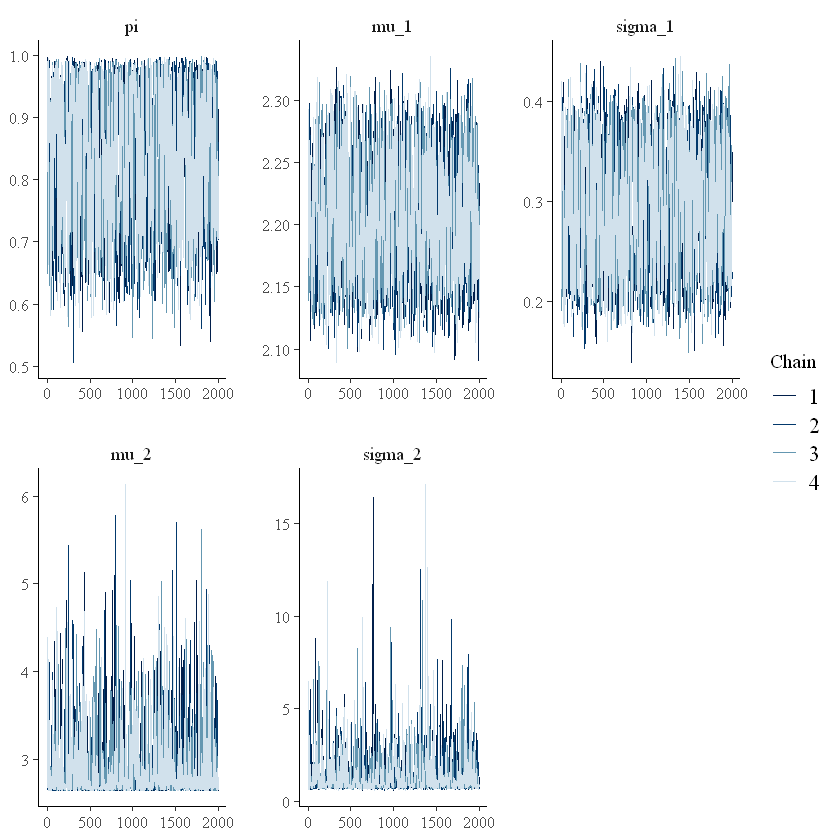

Warning message in par(usr):
"argument 1 does not name a graphical parameter"


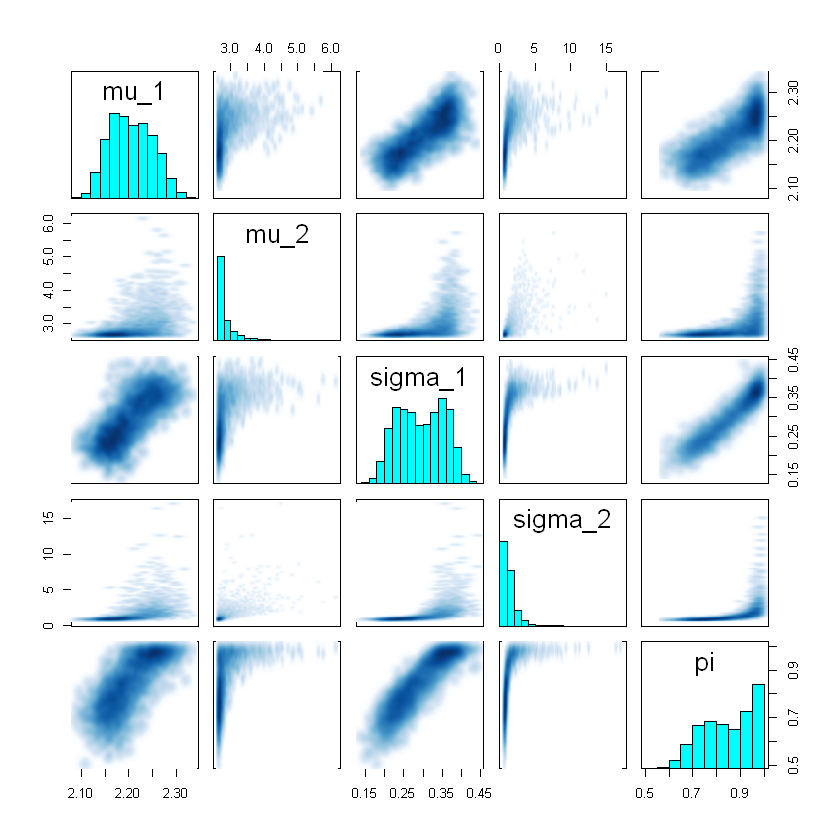

In [11]:
# Plot traceplots for visual convergence check
mcmc_trace(fit_ln, pars = c("pi", "mu_1", "sigma_1", "mu_2", "sigma_2"))

pairs(fit_ln, pars=c("mu_1","mu_2","sigma_1","sigma_2","pi"))